In [1]:
import pickle
import pandas as pd
import os

# 2023

In [3]:
# Définition du dossier
OUTPUT_DIR = '../03_Results'
# Chargement results_wo_peaks_2023_defaut
with open(os.path.join(OUTPUT_DIR, 'results_wo_peaks_2023_defaut.pkl'), 'rb') as f:
    results_wo_peaks_2023_defaut = pickle.load(f)
# Chargement results_wo_peaks_2023
with open(os.path.join(OUTPUT_DIR, 'results_wo_peaks_2023_update.pkl'), 'rb') as f:
    results_wo_peaks_2023_update = pickle.load(f)
# Chargement results_2_peaks_2023
with open(os.path.join(OUTPUT_DIR, 'results_2_peaks_2023.pkl'), 'rb') as f:
    results_2_peaks_2023 = pickle.load(f)
# Chargement results_118_peaks_2023
with open(os.path.join(OUTPUT_DIR, 'results_118_peaks_2023.pkl'), 'rb') as f:
    results_118_peaks_2023 = pickle.load(f)

## F_Mult

In [40]:
# F_Mult

# 1. Extraction, nettoyage et renommage de chaque scénario
df_F_Mult_defaut_clean = results_wo_peaks_2023_defaut.variables['F_Mult'].drop(columns=["Run"], errors="ignore").query("F_Mult != 0").rename(columns={"F_Mult": "Default"})
df_F_Mult_update_clean = results_wo_peaks_2023_update.variables['F_Mult'].drop(columns=["Run"], errors="ignore").query("F_Mult != 0").rename(columns={"F_Mult": "Update"})
df_F_Mult_2_peaks_clean = results_2_peaks_2023.variables['F_Mult'].drop(columns=["Run"], errors="ignore").query("F_Mult != 0").rename(columns={"F_Mult": "2 peaks"})
df_F_Mult_118_peaks_clean = results_118_peaks_2023.variables['F_Mult'].drop(columns=["Run"], errors="ignore").query("F_Mult != 0").rename(columns={"F_Mult": "118 peaks"})

# 2. Concaténation horizontale et alignement automatique
df_F_Mult_comparaison = pd.concat([df_F_Mult_defaut_clean, df_F_Mult_update_clean, df_F_Mult_2_peaks_clean, df_F_Mult_118_peaks_clean], axis=1).fillna(0)

# Définition du seuil de tolérance relative (1% de la valeur Default)
seuil_relatif = 0.01 * df_F_Mult_comparaison["Default"]

# Masque : Écart absolu par rapport à Default supérieur au seuil sur au moins une ligne
masque_difference = df_F_Mult_comparaison.sub(df_F_Mult_comparaison["Default"], axis=0).abs().gt(seuil_relatif, axis=0).any(axis=1)

# Application du filtre sur le DataFrame
df_differences_1percent = df_F_Mult_comparaison[masque_difference]
df_differences_1percent

,Default,Update,2 peaks,118 peaks
DEC_BOILER_GAS,4.492532,4.491980,7.622322,7.616298
DEC_BOILER_OIL,1.617809,1.617610,2.744880,2.742711
DEC_BOILER_WOOD,2.220132,2.219859,3.766821,3.763844
DEC_DIRECT_ELEC,13.619467,13.617791,23.107670,23.089408
DEC_HP_ELEC,2.939435,2.939074,4.987237,4.983295
DHN,0.533269,0.533269,0.860429,0.859749
DHN_BOILER_GAS,0.533269,0.533269,0.860429,0.859749
EHV_GRID,35.948127,29.329863,35.948127,35.948127
HV_GRID,30.680583,30.678784,41.857591,41.837987
IND_BOILER_OIL,2.016389,2.016389,4.857699,5.076832


In [41]:
#Annual_Res

# 1. Extraction, nettoyage et renommage de chaque scénario pour Annual_Res
df_Annual_Res_defaut_clean = results_wo_peaks_2023_defaut.variables['Annual_Res'].drop(columns=["Run"], errors="ignore").query("Annual_Res != 0").rename(columns={"Annual_Res": "Default"})
df_Annual_Res_update_clean = results_wo_peaks_2023_update.variables['Annual_Res'].drop(columns=["Run"], errors="ignore").query("Annual_Res != 0").rename(columns={"Annual_Res": "Update"})
df_Annual_Res_2_peaks_clean = results_2_peaks_2023.variables['Annual_Res'].drop(columns=["Run"], errors="ignore").query("Annual_Res != 0").rename(columns={"Annual_Res": "2 peaks"})
df_Annual_Res_118_peaks_clean = results_118_peaks_2023.variables['Annual_Res'].drop(columns=["Run"], errors="ignore").query("Annual_Res != 0").rename(columns={"Annual_Res": "118 peaks"})

# 2. Concaténation horizontale et alignement automatique
df_Annual_Res_comparaison = pd.concat([df_Annual_Res_defaut_clean, df_Annual_Res_update_clean, df_Annual_Res_2_peaks_clean, df_Annual_Res_118_peaks_clean], axis=1).fillna(0)

# 3. Filtrage par écart de plus de 1% par rapport à Default
seuil_relatif = 0.01 * df_Annual_Res_comparaison["Default"]
masque_difference = df_Annual_Res_comparaison.sub(df_Annual_Res_comparaison["Default"], axis=0).abs().gt(seuil_relatif, axis=0).any(axis=1)

df_differences_res_1percent = df_Annual_Res_comparaison[masque_difference]
df_differences_res_1percent

,Default,Update,2 peaks,118 peaks
BIOMASS_FORESTRY_LEFTOVER1,3.538900e+04,35387.776326,35378.718541,3.448987e+04
CO2_E,7.560327e+07,0.000000,0.000000,9.999939e+09
ELECTRICITY_EHV,3.440168e+04,0.000000,0.000000,0.000000e+00
RES_SOLAR,1.359502e+01,13.595016,13.590497,1.342795e+01
RES_WIND_ONSHORE,1.158712e+04,11587.115328,11582.656264,1.141516e+04
CHURCHILL_FALLS,0.000000e+00,28691.806174,28630.715218,2.800565e+04
ELECTRICITY_OTHER,0.000000e+00,5702.813151,5695.831429,6.861264e+03
BIOMASS_AGRICULTURE_RESIDUAL,0.000000e+00,0.000000,0.000000,8.507710e+02
BIOMASS_FORESTRY_UNEXPLOITED,0.000000e+00,0.000000,0.000000,3.807915e+01


In [37]:
# 1. Définition du seuil de tolérance relative (1% de la valeur Default)
seuil_relatif = 0.01 * df_F_Mult_comparaison["Default"]

# 2. Masque : Écart absolu par rapport à Default supérieur au seuil sur au moins une ligne
masque_difference = df_F_Mult_comparaison.sub(df_F_Mult_comparaison["Default"], axis=0).abs().gt(seuil_relatif, axis=0).any(axis=1)

# 3. Application du filtre sur le DataFrame
df_differences_1percent = df_F_Mult_comparaison[masque_difference]
df_differences_1percent

In [81]:
df_F_Mult_t_2_peaks = results_2_peaks_2023.variables['F_Mult_t'].drop(columns=["Run"], errors="ignore").query("F_Mult_t != 0").unstack()
df_F_Mult_t_2_peaks_clean = df_F_Mult_t_2_peaks[~df_F_Mult_t_2_peaks.index.astype(str).str.startswith(("TRUCK",'CAR','BUS','COACH','COMMUTER','LCV','PLANE','JETFUEL','SEMI','SCHOOLBUS','SUV','TRAIN','TRAFO','BULK'))]


df_F_Mult_t_2_peaks_clean.columns = df_F_Mult_t_2_peaks_clean.columns.get_level_values('index1')

df_F_Mult_t_2_peaks_clean[14]

index0
BIOMASS_FORESTRY_LEFTOVER1    8.661067e+00
BIOMASS_FORESTRY_LEFTOVER2             NaN
BIOMASS_WASTE_BUILDING                 NaN
CEMENT                        1.000000e+04
CHURCHILL_FALLS               5.428000e+00
COAL                          4.333610e-01
CONTAINER                     1.257189e+00
CONTAINER_ELD                 1.257189e+00
DEC_BOILER_GAS                7.622322e+00
DEC_BOILER_OIL                2.744880e+00
DEC_BOILER_WOOD               3.766821e+00
DEC_DIRECT_ELEC               2.310767e+01
DEC_HP_ELEC                   4.987237e+00
DEC_TH_STORAGE                4.664903e-02
DHN                           8.604288e-07
DHN_BOILER_GAS                         NaN
DHN_TH_STORAGE                         NaN
DIESEL                        4.091913e+00
EHP_NG_GRID                   9.670442e+00
EHV_GRID                      3.594813e+01
ELECTRICITY_OTHER             6.348720e+00
GASOLINE                      8.543918e+00
HFO                           5.935560e-01
HP_N

In [20]:
df.index

Index(['AFC', 'ALKALINE_ELECTROLYSIS', 'AL_MAKING', 'AL_MAKING_HR', 'AN_DIG',
       'AN_DIG_SI', 'ATR', 'ATR_CCS', 'BATTERY', 'BIOETHANOL_TO_BIOJETFUELS',
       ...
       'TRUCK_SH_HY_DIESEL', 'TRUCK_SH_HY_DIESEL_MD', 'TRUCK_SH_HY_DIESEL_SD',
       'TRUCK_SH_PROPANE', 'TRUCK_SH_PROPANE_MD', 'TRUCK_SH_PROPANE_SD',
       'UNMINEABLE_COAL_SEAM', 'WIND_OFFSHORE', 'WIND_ONSHORE',
       'WOOD_METHANOL'],
      dtype='object', length=689)

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_tech_distribution_two_subplots(
    results_peak,
    results_wo_peaks,
    period_labels,
    periods_wo=[1, 2],
    periods_peak=[1, 2, 13, 14]
):
    # ==================================================
    # 1) EXTRACTION DES TECHNOLOGIES ET COEFFICIENTS ELEC
    # ==================================================
    layers = results_peak.parameters["layers_in_out"].drop(columns="Run", errors="ignore")
    is_elec = layers.index.get_level_values(1).str.startswith("ELEC")
    coeff_by_tech = layers[is_elec & (layers > 0).any(axis=1)]["layers_in_out"].groupby(level=0).first()

    # Ressources spécifiques à traiter manuellement
    specific_resources = ["CHURCHILL_FALLS", "ELECTRICITY_EHV", "ELECTRICITY_OTHER"]
    valid_techs = [t for t in coeff_by_tech.index if t not in specific_resources]

    # Mapping de renommage avec agrégation des deux types d'importations
    TECH_LABELS = {
        "GAS_CENTRAL": "Centrale - Gaz",
        "CCGT": "CCGT",
        "HYDRO_DAM": "Hydro - Barrage",
        "HYDRO_RIVER": "Hydro - Rivières",
        "PV_ROOF": "PV toiture",
        "PV_GROUND": "PV sol",
        "WIND_ONSHORE": "Éolien terrestre",
        "WIND_OFFSHORE": "Éolien en mer",
        "CHURCHILL_FALLS": "Churchill Falls",
        "ELECTRICITY_EHV": "Autres importations",    # Agrégé ici
        "ELECTRICITY_OTHER": "Autres importations"  # Agrégé ici
    }

    # ==================================================
    # 2) FONCTION INTERNE SIMPLIFIÉE POUR CONSTRUIRE LE DF
    # ==================================================
    def build_clean_df(results, period_ids):
        f_mult_all = results.variables["F_Mult_t"].drop(columns="Run", errors="ignore")

        # 1. Traitement des technos standards de production
        f_mult = f_mult_all[f_mult_all.index.get_level_values("index0").isin(valid_techs) & (f_mult_all > 0).any(axis=1)]
        f_weighted = f_mult.mul(f_mult.index.get_level_values("index0").map(coeff_by_tech), axis=0)

        df = f_weighted["F_Mult_t"].unstack(level="index1")[period_ids].fillna(0)
        df.columns = [period_labels[i - 1] for i in period_ids]

        # 2. Extraction manuelle des ressources spécifiques
        for res in specific_resources:
            try:
                if res in f_mult_all.index.get_level_values(0):
                    res_data = f_mult_all.loc[res]["F_Mult_t"].reindex(period_ids).fillna(0)
                    df.loc[res] = res_data.values
            except KeyError:
                pass

        # Renommer les index (les doublons "Autres importations" apparaissent ici)
        df = df.rename(index=TECH_LABELS)

        # SOMME DES DOUBLONS : Fusionne "Autres importations" (EHV + OTHER) par le biais de l'index
        df = df.groupby(level=0).sum()

        # 3. SÉPARATION ENTRE LES TECHNOS PRINCIPALES ET LE RESTE ("Other")
        is_main = df.index.isin(TECH_LABELS.values())
        df_main = df[is_main].copy()
        df_other = df[~is_main]

        # Nettoyage des résidus indésirables
        df_other = df_other[~df_other.index.str.startswith("TRAFO") & (~df_other.index.isin(["IND_COGEN_WOOD"]))]

        if not df_other.empty and df_other.sum().sum() > 0:
            df_main.loc["Other"] = df_other.sum(axis=0)

        return df_main

    # ==================================================
    # 3) TRAITEMENT ET ALIGNEMENT DES DEUX DATASETS
    # ==================================================
    df_wo = build_clean_df(results_wo_peaks, periods_wo)
    df_peak = build_clean_df(results_peak, periods_peak)

    # Alignement de l'ordre visuel
    tech_order = list(dict.fromkeys(list(df_wo.index) + list(df_peak.index)))

    # --- MODIFICATION DE L'ORDRE ICI ---
    # Inversion de l'ordre d'insertion pour placer "Autres importations" puis "Churchill Falls" au sommet
    for r_item in ["Churchill Falls", "Autres importations"]:
        if r_item in tech_order:
            tech_order.remove(r_item)
            tech_order.append(r_item)

    df_wo = df_wo.reindex(tech_order).fillna(0)
    df_peak = df_peak.reindex(tech_order).fillna(0)

    # Nettoyage des lignes vides
    non_zero = (df_wo.sum(axis=1) + df_peak.sum(axis=1)) > 0
    df_wo, df_peak = df_wo[non_zero], df_peak[non_zero]
    tech_order = df_wo.index.tolist()

    # ==================================================
    # AFFICHAGE DES DATAFRAMES DANS LA CONSOLE (ORDRE INVERSÉ)
    # ==================================================
    print("\n" + "="*50)
    print(" RÉSULTATS : SANS POINTE")
    print("="*50)
    print(df_wo.round(2))

    print("\n" + "="*50)
    print(" RÉSULTATS : AVEC POINTE")
    print("="*50)
    print(df_peak.round(2))
    print("="*50 + "\n")

    # ==================================================
    # 4) TRACÉ DES GRAPHIQUES (SUBPLOTS)
    # ==================================================
    base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    if len(tech_order) > len(base_colors):
        base_colors = base_colors * 2

    color_map = {tech: base_colors[i % len(base_colors)] for i, tech in enumerate(tech_order)}
    color_list = [color_map[tech] for tech in tech_order]

    fig, axes = plt.subplots(
        ncols=2, figsize=(13, 6), sharey=True,
        gridspec_kw={"width_ratios": [df_wo.shape[1], df_peak.shape[1]]}
    )

    # Subplot 1 : Sans pointe
    df_wo.T.plot(kind="bar", stacked=True, ax=axes[0], color=color_list, legend=False)
    axes[0].set_title("Sans pointe", fontsize=12, fontweight="bold")
    axes[0].set_ylabel("Puissance [GW]", fontsize=11)
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].grid(axis="y", linestyle="--", alpha=0.5)

    # Subplot 2 : Avec pointe
    df_peak.T.plot(kind="bar", stacked=True, ax=axes[1], color=color_list, legend=False)
    axes[1].set_title("Avec pointe", fontsize=12, fontweight="bold")
    axes[1].tick_params(axis="x", rotation=30)
    axes[1].grid(axis="y", linestyle="--", alpha=0.5)

    # Légende unique
    legend_handles = [Patch(facecolor=color_map[tech], label=tech) for tech in tech_order]
    fig.legend(handles=legend_handles, title="Technologies / Contrats", loc="center left", bbox_to_anchor=(0.84, 0.5))

    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.show()


 RÉSULTATS : SANS POINTE
                     Janvier  Février
index0                               
Hydro - Barrage        18.95    18.74
Hydro - Rivières       10.38    10.26
PV toiture              0.00     0.00
Éolien terrestre        1.39     1.54
Churchill Falls         5.40     4.57
Autres importations     0.00     0.00

 RÉSULTATS : AVEC POINTE
                     Janvier  Février  Pointe - Janvier  Pointe - Février
index0                                                                   
Hydro - Barrage        18.95    18.74             22.33             22.33
Hydro - Rivières       10.38    10.26             13.62             13.62
PV toiture              0.00     0.00              0.00              0.00
Éolien terrestre        1.39     1.54              0.00              0.00
Churchill Falls         5.21     5.06              5.43              5.43
Autres importations     0.00     0.00              1.87              6.35



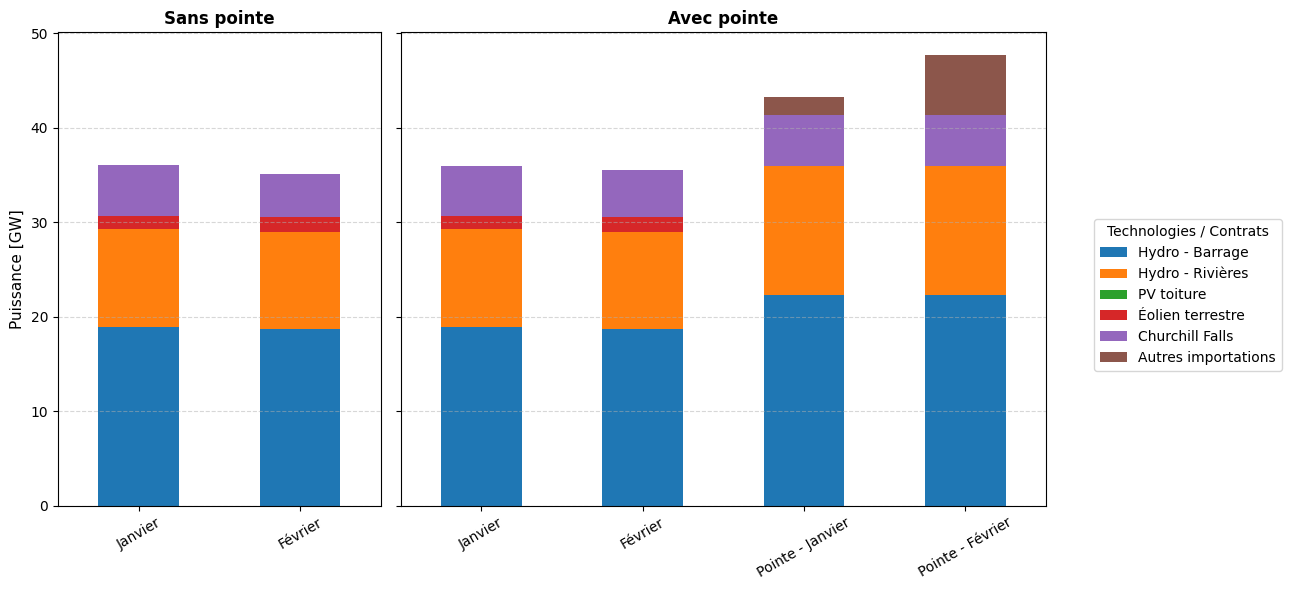

In [14]:
# Exemple de labels pour tes périodes (à adapter selon ton modèle Energyscope)
# Il faut une liste d'au moins 14 éléments puisque periods_peak contient l'ID 14
period_labels = [
    # 1–2 : Janvier–Février
    "Janvier", "Février",

    # 3–12 : autres mois
    "Mars", "Avril", "Mai", "Juin", "Juillet", "Août", "Septembre", "Octobre", "Novembre", "Décembre",

    # 13–4 : périodes de pointe
    "Pointe - Janvier", "Pointe - Février",
]

# Appel direct de la fonction
plot_tech_distribution_two_subplots(
    results_peak=results_2_peaks_2023,
    results_wo_peaks=results_wo_peaks_2023_update,
    period_labels=period_labels,
    periods_wo=[1, 2],         # Les IDs de périodes à afficher pour le graph "Sans pointe"
    periods_peak=[1, 2, 13, 14] # Les IDs de périodes à afficher pour le graph "Avec pointe"
)

In [25]:
results_2_peaks_2023.variables['F_Mult_t'].loc[['CHURCHILL_FALLS', 'ELECTRICITY_OTHER', 'ELECTRICITY_EHV']]

F_Mult_t  Run
index0            index1                
CHURCHILL_FALLS   1        5.204300    0
                  2        4.267083    0
                  3        3.316937    0
                  4        0.005759    0
                  5        0.239110    0
                  6        2.043077    0
                  7        3.270410    0
                  8        0.000000    0
                  9        0.000000    0
                  10       6.201645    0
                  11       7.731877    0
                  12       8.747879    0
                  13       7.287691    0
                  14      11.764385    0
ELECTRICITY_OTHER 1        0.000000    0
                  2        0.000000    0
                  3        0.000000    0
                  4        0.000000    0
                  5        0.000000    0
                  6        0.000000    0
                  7        0.000000    0
                  8        2.230531    0
                  9        2.324920    0
                  10       1.297699    0
                  11       0.000000    0
                  12       0.000000    0
                  13       0.000000    0
                  14       0.000000    0
ELECTRICITY_EHV   1        0.000000    0
                  2        0.000000    0
                  3        0.000000    0
                  4        0.000000    0
                  5        0.000000    0
                  6        0.000000    0
                  7        0.000000    0
                  8        0.000000    0
                  9        0.000000    0
                  10       0.000000    0
                  11       0.000000    0
                  12       0.000000    0
                  13       0.000000    0
                  14       0.000000    0

In [26]:
results_wo_peaks_2023_update.variables['F_Mult_t'].loc[['CHURCHILL_FALLS', 'ELECTRICITY_OTHER', 'ELECTRICITY_EHV']]

F_Mult_t  Run
index0            index1               
CHURCHILL_FALLS   1       5.402557    0
                  2       4.323136    0
                  3       3.442171    0
                  4       0.133841    0
                  5       0.325646    0
                  6       2.045805    0
                  7       3.356946    0
                  8       0.000000    0
                  9       0.000000    0
                  10      5.275877    0
                  11      7.994297    0
                  12      8.768865    0
ELECTRICITY_OTHER 1       0.000000    0
                  2       0.000000    0
                  3       0.000000    0
                  4       0.000000    0
                  5       0.000000    0
                  6       0.000000    0
                  7       0.000000    0
                  8       1.691210    0
                  9       1.792153    0
                  10      2.481195    0
                  11      0.000000    0
                  12      0.000000    0
ELECTRICITY_EHV   1       0.000000    0
                  2       0.000000    0
                  3       0.000000    0
                  4       0.000000    0
                  5       0.000000    0
                  6       0.000000    0
                  7       0.000000    0
                  8       0.000000    0
                  9       0.000000    0
                  10      0.000000    0
                  11      0.000000    0
                  12      0.000000    0

In [27]:
# 1. Recréer les filtres d'électricité exactement comme dans la fonction
layers = results_2_peaks_2023.parameters["layers_in_out"].drop(columns="Run", errors="ignore")
is_elec = layers.index.get_level_values(1).str.startswith("ELEC")
coeff_by_tech = layers[is_elec & (layers > 0).any(axis=1)]["layers_in_out"].groupby(level=0).first()
valid_techs = coeff_by_tech.index

# 2. Extraire F_Mult_t pour les périodes de pointe
f_mult_all = results_2_peaks_2023.variables["F_Mult_t"].drop(columns="Run", errors="ignore")
f_mult = f_mult_all[f_mult_all.index.get_level_values("index0").isin(valid_techs) & (f_mult_all > 0).any(axis=1)]
f_weighted = f_mult.mul(f_mult.index.get_level_values("index0").map(coeff_by_tech), axis=0)

# 3. Pivoter et filtrer pour ne garder QUE ce qui n'est PAS dans tes TECH_LABELS principaux
periods_peak = [1, 2, 13, 14]  # Tes périodes avec pointe
df_all_techs = f_weighted["F_Mult_t"].unstack(level="index1")[periods_peak].fillna(0)

# Nettoyage initial identique à ton code
df_all_techs = df_all_techs[~df_all_techs.index.str.startswith("TRAFO") & (~df_all_techs.index.isin(["IND_COGEN_WOOD", "ELECTRICITY_EHV"]))]

# Filtrer pour exclure les techs principales connues
known_techs = ["GAS_CENTRAL", "CCGT", "ELECTRICITY_IMPORT", "HYDRO_DAM", "HYDRO_RIVER", "PV", "PV_ROOF", "WIND", "WIND_ONSHORE"]
df_other_hidden = df_all_techs[~df_all_techs.index.isin(known_techs)]

# 4. Afficher le total cumulé sur ces périodes trié par importance
print("--- TECHNOLOGIES CACHÉES DANS 'OTHER' PENDANT LES POINTES ---")
print(df_other_hidden.sum(axis=1).sort_values(ascending=False))

--- TECHNOLOGIES CACHÉES DANS 'OTHER' PENDANT LES POINTES ---
index0
CHURCHILL_FALLS      28.523459
ELECTRICITY_OTHER     0.000000
dtype: float64


In [28]:
# 1. Vérifier si ELECTRICITY_OTHER est traité comme une technologie ou une ressource
print("--- SENS DE PRODUCTION / CONSOMMATION ---")
try:
    # On regarde dans layers_in_out comment ELECTRICITY_OTHER interagit avec l'électricité
    layers_subset = results_2_peaks_2023.parameters["layers_in_out"].xs("ELECTRICITY_OTHER", level=0, drop_level=False)
    print("Coefficients dans layers_in_out pour ELECTRICITY_OTHER :")
    print(layers_subset)
except KeyError:
    print("ELECTRICITY_OTHER n'est pas défini dans les technologies de layers_in_out.")

# 2. Extraction brute de sa production par période de pointe
print("\n--- VALEURS BRUTES PENDANT LES POINTES ---")
try:
    f_mult_other = results_2_peaks_2023.variables["F_Mult_t"].loc["ELECTRICITY_OTHER"]["F_Mult_t"]
    print("Production brute de ELECTRICITY_OTHER aux périodes demandées :")
    print(f_mult_other.loc[[1, 2, 13, 14]])
except KeyError:
    print("Pas de variable F_Mult_t pour ELECTRICITY_OTHER.")

--- SENS DE PRODUCTION / CONSOMMATION ---
Coefficients dans layers_in_out pour ELECTRICITY_OTHER :
                                                 layers_in_out  Run
index0            index1                                           
ELECTRICITY_OTHER ACETIC_ACID                              0.0    0
                  ACETONE                                  0.0    0
                  ALUMINUM                                 0.0    0
                  BENZENE                                  0.0    0
                  BIOMASS_AGRICULTURE_DEJECTION            0.0    0
...                                                        ...  ...
                  WASTE_BIO                                0.0    0
                  WASTE_FOS                                0.0    0
                  WET_BIOMASS                              0.0    0
                  WOOD                                     0.0    0
                  XYLENE                                   0.0    0

[98 rows x 2 col

In [29]:
import pandas as pd

# 1. Extraction des puissances totales sur les périodes de pointe pour comparer les échelles
periods_peak = [1, 2, 13, 14]

# Production cumulée de ELECTRICITY_OTHER sur ces pointes
f_mult_all = results_2_peaks_2023.variables["F_Mult_t"].drop(columns="Run", errors="ignore")
val_other = f_mult_all.loc["ELECTRICITY_OTHER"]["F_Mult_t"].loc[periods_peak]

# Production cumulée d'une techno de référence (ex: HYDRO_DAM) pour voir le ratio d'unité
try:
    val_hydro = f_mult_all.loc["HYDRO_DAM"]["F_Mult_t"].loc[periods_peak]
    comparison_df = pd.DataFrame({"ELECTRICITY_OTHER": val_other, "HYDRO_DAM": val_hydro})

    print("--- COMPARAISON DES ORDRES DE GRANDEUR (VÉRIFICATION UNITÉ) ---")
    print(comparison_df)
    print("\nRatio OTHER / HYDRO :")
    print(val_other / val_hydro.replace(0, 1)) # Évite la division par zéro
except KeyError:
    print("HYDRO_DAM non trouvé, voici les valeurs brutes de ELECTRICITY_OTHER :")
    print(val_other)

--- COMPARAISON DES ORDRES DE GRANDEUR (VÉRIFICATION UNITÉ) ---
        ELECTRICITY_OTHER  HYDRO_DAM
index1                              
1                     0.0  18.950683
2                     0.0  18.739827
13                    0.0  22.331127
14                    0.0  22.331127

Ratio OTHER / HYDRO :
index1
1     0.0
2     0.0
13    0.0
14    0.0
Name: F_Mult_t, dtype: float64


## Couts

                Sans pointe  2 pointes  118 pointes
Investissement    45.165345  47.722994    47.721742
Maintenance       26.232274  26.483585    26.483779
Opération         28.602381  28.588576    28.132619


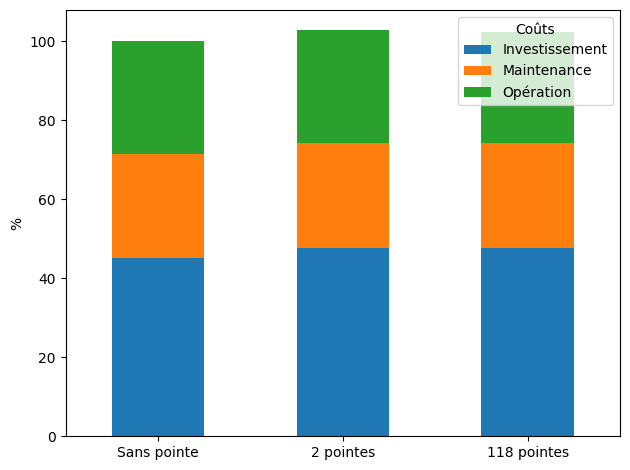

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Configuration des scénarios à comparer
scenarios = {
    "Sans pointe": results_wo_peaks_2023_update,
    "2 pointes": results_2_peaks_2023,
    "118 pointes": results_118_peaks_2023
}

# 2. Fonction d'extraction et de sommation des coûts
def extraire_couts(res_obj):
    c_inv = pd.Series([res_obj.postprocessing['df_annual']['C_inv_an'].sum()], index=['C_inv'])
    c_maint = res_obj.variables['C_maint'].drop(columns='Run', errors='ignore').sum()
    c_op = res_obj.variables['C_op'].drop(columns='Run', errors='ignore').sum()
    return pd.concat([c_inv, c_maint, c_op])

# 3. Construction vectorisée du DataFrame comparatif
df_couts = pd.DataFrame({nom: extraire_couts(res) for nom, res in scenarios.items()})
df_couts.index = ['Investissement', 'Maintenance', 'Opération']

# 4. Normalisation (%) par rapport au total du scénario de référence choisi
reference = "Sans pointe"
df_couts_norm = df_couts.div(df_couts[reference].sum()) * 100

# 5. Affichage des résultats numériques et génération du graphique
print(df_couts_norm)

df_couts_norm.T.plot(kind="bar", stacked=True)
plt.ylabel("%")
plt.xticks(rotation=0)
plt.legend(title="Coûts", loc="upper right")
plt.tight_layout()

## CO2

In [97]:
results_2_peaks_2023.variables['GWP'].drop(columns='Run').unstack()

GWP                                                              \
index1        1         2         3         4         5         6         7    
index0                                                                         
CO2_A   3.253401  2.274201  3.204924  2.306065  3.139988  3.140479  3.140479   
CO2_C   0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
CO2_CS  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
CO2_E   3.891114  5.438811  3.572735  4.417970  2.766948  2.766948  2.766948   
CO2_EE  1.919225  2.002667  1.814434  1.699625  1.537470  1.537650  1.537650   
CO2_S   0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   

                                                                              
index1        8         9         10        11        12        13        14  
index0                                                                        
CO2_A   3.335996  3.147368  3.181205  3.177027  3.308349  3.682232  3.508425  
CO2_C   0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  
CO2_CS  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  
CO2_E   2.766948  2.853084  4.275728  4.689708  5.614086  5.442111  8.010582  
CO2_EE  1.498821  1.567238  1.712564  1.797702  1.946327  0.000000  0.000000  
CO2_S   0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000

            Sans pointe     2 pointes   118 pointes
Total GWP  60154.613987  60146.588489  1.000000e+10


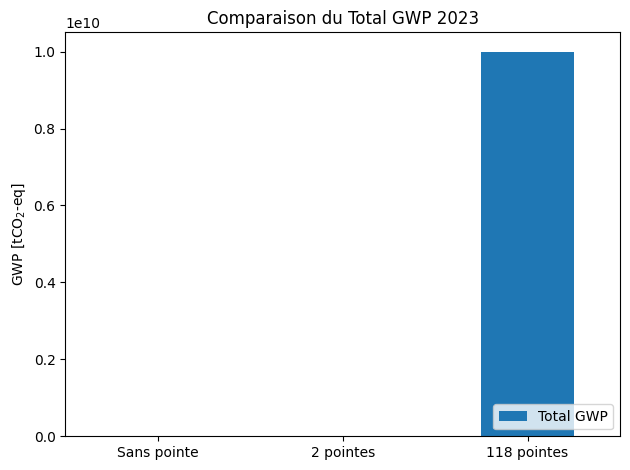

In [98]:
import pandas as pd
import matplotlib.pyplot as plt

scenarios = {
    "Sans pointe": results_wo_peaks_2023_update,
    "2 pointes": results_2_peaks_2023,
    "118 pointes": results_118_peaks_2023
}


# 1. Extraction vectorisée du Total GWP pour chaque scénario
df_gwp = pd.DataFrame({
    nom: [res.variables['TotalGWP'].drop(columns='Run', errors='ignore').values.sum()]
    for nom, res in scenarios.items()
}, index=["Total GWP"])

# 2. Affichage des résultats numériques
print(df_gwp)

# 3. Génération et sauvegarde du graphique comparatif
df_gwp.T.plot(kind="bar")
plt.ylabel("GWP [t$\\text{CO}_2$-eq]")
plt.xticks(rotation=0)
plt.title("Comparaison du Total GWP 2023")
plt.legend(loc="lower right")
plt.tight_layout()

# 2050

In [101]:
# Définition du dossier
OUTPUT_DIR = '../03_Results'
# Chargement
with open(os.path.join(OUTPUT_DIR, 'results_wo_peaks_2050.pkl'), 'rb') as f:
    results_wo_peaks_2050 = pickle.load(f)
with open(os.path.join(OUTPUT_DIR, 'results_wo_peaks_2050_carboneutre.pkl'), 'rb') as f:
    results_wo_peaks_2050_carboneutre = pickle.load(f)
with open(os.path.join(OUTPUT_DIR, 'results_wo_peaks_2050_carboneutre_planHQ.pkl'), 'rb') as f:
    results_wo_peaks_2050_carboneutre_planHQ = pickle.load(f)

with open(os.path.join(OUTPUT_DIR, 'results_peaks_2050_carboneutre.pkl'), 'rb') as f:
    results_peaks_2050_carboneutre = pickle.load(f)
with open(os.path.join(OUTPUT_DIR, 'results_peaks_2050_carboneutre_planHQ.pkl'), 'rb') as f:
    results_peaks_2050_carboneutre_planHQ = pickle.load(f)


In [106]:
F_Mult_2050 = results_wo_peaks_2050.variables['F_Mult']
# Sélection des lignes dont l'index commence par 'SUC'
df_suv = F_Mult_2050[F_Mult_2050.index.str.startswith('SUV')]

# Affichage du résultat
print(df_suv.sum())

F_Mult    0.0
Run       0.0
dtype: float64
